<a href="https://colab.research.google.com/github/Megha-alt/-Live-Earthquake-Monitoring-and-ML-Risk-Predictor/blob/main/SEISMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEISMO : Real Time Earthquake Area-Based Risk Analysis

In [80]:
import pandas as pd
import numpy as np
import requests
from datetime import timedelta
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [81]:


url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2023-01-01"
    "&endtime=2023-12-31"
    "&minmagnitude=4"
)

# fetching dataset:
headers = { "User-Agent": "Mozilla/5.0" }
response = requests.get(url, headers=headers)
print(response.status_code)

with open("usgs_earthquake_data.csv", "wb") as f:
    f.write(response.content)



200


In [82]:
df = pd.read_csv("usgs_earthquake_data.csv")
print(df.head())
print(df.info())



                       time  latitude  longitude    depth  mag magType   nst  \
0  2023-12-30T23:55:48.472Z   44.6077   148.9343   35.000  4.4      mb  48.0   
1  2023-12-30T23:34:10.971Z   -3.6423  -102.9478   10.000  4.6      mb  63.0   
2  2023-12-30T22:39:19.128Z   40.0474   142.1067   48.231  4.3      mb  42.0   
3  2023-12-30T22:37:46.030Z  -23.2547  -179.4246  561.074  4.3      mb  22.0   
4  2023-12-30T22:19:31.590Z   16.5191   145.4075  311.398  4.2      mb  41.0   

     gap    dmin   rms  ...                   updated  \
0  199.0   4.573  0.58  ...  2024-03-02T21:39:34.040Z   
1  160.0  21.509  0.63  ...  2024-03-02T21:39:34.040Z   
2  164.0   1.087  0.52  ...  2024-03-02T21:39:34.040Z   
3  104.0   4.427  0.35  ...  2024-03-02T21:39:37.040Z   
4  112.0   1.323  0.51  ...  2024-03-02T21:39:37.040Z   

                                            place        type horizontalError  \
0                   108 km SE of Kuril’sk, Russia  earthquake           12.43   
1             

In [83]:
print(df.describe())


           latitude     longitude         depth           mag           nst  \
count  16190.000000  16190.000000  16190.000000  16190.000000  16133.000000   
mean       4.166936     42.158144     86.092049      4.510338     50.479018   
std       27.976125    119.032997    138.258510      0.394445     42.460137   
min      -65.849700   -179.997500      0.000000      4.000000      0.000000   
25%      -17.917325    -68.838250     10.000000      4.300000     23.000000   
50%        2.648900     99.392950     29.106500      4.400000     36.000000   
75%       27.764725    140.093600     95.247250      4.600000     63.000000   
max       86.593900    179.999400    681.238000      7.800000    466.000000   

                gap          dmin           rms  horizontalError  \
count  16132.000000  16121.000000  16190.000000     16130.000000   
mean     101.308882      3.549250      0.665581         8.537805   
std       43.624790      4.454062      0.212446         3.239213   
min        8.000

In [84]:
#DROP columns NOT required for ML
df = df[[ "time", "latitude", "longitude", "depth", "mag" ]]

df.rename(columns={"mag": "magnitude"}, inplace=True)

#Convert time to datetime
df["time"] = pd.to_datetime(df["time"], utc=True)
df["time"] = pd.to_datetime(df["time"], errors="coerce")

#Handle missing values:
df.isnull().sum()
df.dropna(subset=["time", "magnitude", "depth"], inplace=True)

#Removing invalid values:
df = df[(df["magnitude"] >= 0) & (df["depth"] >= 0)]

#Removing duplicates:
df.drop_duplicates(inplace=True)

#sort Timing:
df = df.sort_values("time").reset_index(drop=True)

df.head()


,time,latitude,longitude,depth,magnitude
0,2023-01-01 01:41:43.755000+00:00,7.1397,126.7380,79.194,4.5
1,2023-01-01 03:16:14.442000+00:00,-6.7065,155.2320,35.000,5.4
2,2023-01-01 04:09:32.814000+00:00,-4.7803,102.7675,63.787,4.3
3,2023-01-01 04:54:53.914000+00:00,-19.0419,-177.5423,556.990,4.1
4,2023-01-01 05:02:46.402000+00:00,-15.3219,-174.8756,255.470,4.1


In [85]:
from datetime import timedelta
df["lat_bin"] = df["latitude"].round(0)
df["lon_bin"] = df["longitude"].round(0)

df = df.sort_values("time")

df["count_1h"] = 0
df["avg_mag_6h"] = 0.0
df["max_mag_24h"] = 0.0
df["avg_depth_6h"] = 0.0

for (latb, lonb), g in df.groupby(["lat_bin", "lon_bin"]):
    for i, row in g.iterrows():
        t = row["time"]

        last_1h = g[g["time"] >= t - timedelta(hours=1)]
        last_6h = g[g["time"] >= t - timedelta(hours=6)]
        last_24h = g[g["time"] >= t - timedelta(hours=24)]

        df.at[i, "count_1h"] = len(last_1h)
        df.at[i, "avg_mag_6h"] = last_6h["magnitude"].mean()
        df.at[i, "max_mag_24h"] = last_24h["magnitude"].max()
        df.at[i, "avg_depth_6h"] = last_6h["depth"].mean()


In [86]:
df["risk_label"] = (
    (
        (df["count_1h"] >= 6) &           # strong clustering
        (df["avg_mag_6h"] >= 4.5) &        # sustained intensity
        (df["avg_depth_6h"] <= 70)         # shallow events
    ) |
    (df["max_mag_24h"] >= 6.0)             # strong standalone quake
).astype(int)



feature_cols = [
    "magnitude",
    "depth",
    "latitude",
    "longitude",
    "count_1h",
    "avg_mag_6h",
    "max_mag_24h",
    "avg_depth_6h"
]

x = df[feature_cols]
y = df["risk_label"]

# Split train
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y )


In [98]:

# Build ML pipeline
from sklearn.ensemble import RandomForestClassifier


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])
#Train Model
pipeline.fit(X_train, y_train)





Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=14,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

In [99]:
feature_importance = pipeline.named_steps["rf"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

# saving model
import joblib
joblib.dump(pipeline, "earthquake_risk_pipeline.joblib")


        Feature  Importance
6   max_mag_24h    0.315319
4      count_1h    0.275657
5    avg_mag_6h    0.243658
7  avg_depth_6h    0.079977
1         depth    0.026375
3     longitude    0.022061
0     magnitude    0.018556
2      latitude    0.018397


['earthquake_risk_pipeline.joblib']

In [89]:
df["risk_label"].value_counts(normalize=True)

print("Training label distribution:")
print(y_train.value_counts())

print("\nFull dataset label distribution:")
print(df["risk_label"].value_counts())

Training label distribution:
risk_label
0    9287
1    3665
Name: count, dtype: int64

Full dataset label distribution:
risk_label
0    11609
1     4581
Name: count, dtype: int64


In [100]:
from math import radians, sin, cos, sqrt, atan2
#distance between two points on Earth (in km)
def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(
        radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


# filtering by radius:
def filter_by_radius(df, lat, lon, radius_km):
    df["distance_km"] = df.apply(
        lambda r: haversine(lat, lon, r["latitude"], r["longitude"]),
        axis=1
    )
    return df[df["distance_km"] <= radius_km]

In [101]:
# REAL TIME DATA
from datetime import datetime


url1 = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"
data = requests.get(url1).json()

records = []
for eq in data["features"]:
    props = eq["properties"]
    coords = eq["geometry"]["coordinates"]

    records.append({
        "time": pd.to_datetime(props["time"], unit="ms", utc=True),
        "latitude": coords[1],
        "longitude": coords[0],
        "depth": coords[2],
        "magnitude": props["mag"]
    })


df_live = pd.DataFrame(records)
df_live.head()
df_live.describe
print("Enter latitude , longitude and radius in km . example set[ 60.0 , -150.0 , 600]")
user_lat = float(input("Enter latitude:"))
user_lon = float(input("Enter longitude:"))
radius_km = float(input("Enter radius (km):"))


df_region = filter_by_radius(df_live, user_lat, user_lon, radius_km).copy()
df_region["time"] = pd.to_datetime(df_region["time"], utc=True)


import matplotlib.pyplot as plt




if df_region.empty:
    print("⚠️ No earthquakes found in this region.")
else:
    now = df_region["time"].max()

    last_1h  = df_region[df_region["time"] >= now - timedelta(hours=1)]
    last_6h  = df_region[df_region["time"] >= now - timedelta(hours=6)]
    last_24h = df_region[df_region["time"] >= now - timedelta(hours=24)]


    # Plot last 24 hours



X_live = pd.DataFrame([{
    "magnitude": df_region.iloc[-1]["magnitude"] if not df_region.empty else 0,
    "depth": df_region.iloc[-1]["depth"] if not df_region.empty else 0,
    "latitude": user_lat,
    "longitude": user_lon,
    "count_1h": len(last_1h),
    "avg_mag_6h": last_6h["magnitude"].mean() if not last_6h.empty else 0,
    "max_mag_24h": last_24h["magnitude"].max() if not last_24h.empty else 0,
    "avg_depth_6h": last_6h["depth"].mean() if not last_6h.empty else 0
}])


risk = pipeline.predict(X_live)[0]
pred = pipeline.predict_proba(X_live)[0][1]

confidence_text = f"{pred*100:.2f}%"

risk_level = "HIGH RISK" if pred == 1 else "LOW RISK"

print("📍Earthquake Area-Based Risk Analysis")
print("--------------------")
print(f"Risk Level     : {risk_level}")
print(f"Confidence     : {confidence_text}")
print(f"Recent Events  : {X_live['count_1h'].iloc[0]} in last 1 hour")
print(f"Max Mag (24h)  : {X_live['max_mag_24h'].iloc[0]}")
print(f"Avg Depth (6h) : {X_live['avg_depth_6h'].iloc[0]:.1f} km")


Enter latitude , longitude and radius in km . example set[ 60.0 , -150.0 , 600]
Enter latitude:60.0
Enter longitude:-150.0
Enter radius (km):600
📍Earthquake Area-Based Risk Analysis
--------------------
Risk Level     : LOW RISK
Confidence     : 0.24%
Recent Events  : 2 in last 1 hour
Max Mag (24h)  : 3.4
Avg Depth (6h) : 53.5 km


[[2319    3]
 [   0  916]]
              precision    recall  f1-score   support

           0     1.0000    0.9987    0.9994      2322
           1     0.9967    1.0000    0.9984       916

    accuracy                         0.9991      3238
   macro avg     0.9984    0.9994    0.9989      3238
weighted avg     0.9991    0.9991    0.9991      3238



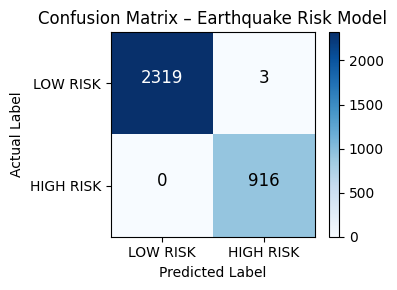

In [102]:
# Precision, recall ,f1 score, and support sore
from sklearn.metrics import classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred , digits=4))
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(4, 3))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix – Earthquake Risk Model")
plt.colorbar()

classes = ["LOW RISK", "HIGH RISK"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add numbers inside boxes
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=12
        )

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

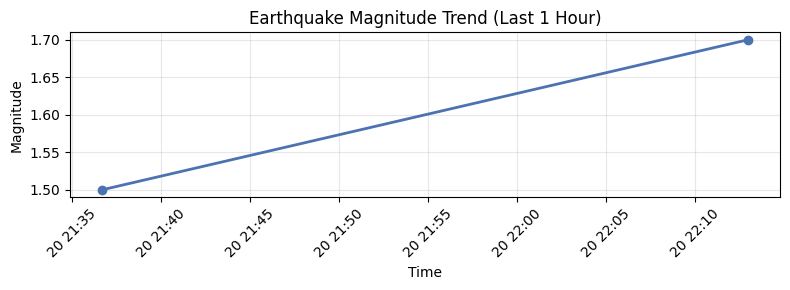

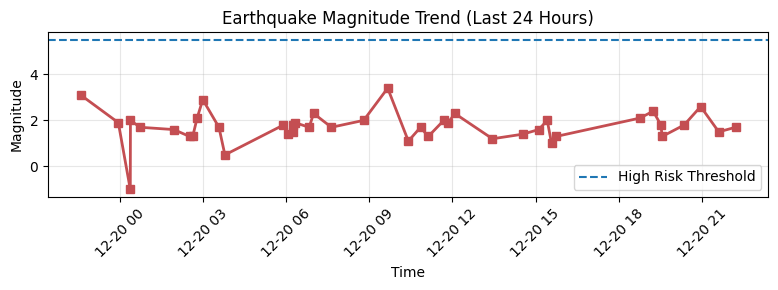

In [103]:
# Exploratory Data Analysis
#Earthquake Magnitude Trend (Last 1 Hour)
import matplotlib.pyplot as plt

if not last_1h.empty:
    plt.figure(figsize=(8,3))
    plt.plot(
        last_1h["time"],
        last_1h["magnitude"],
        marker="o",
         color="#4C72B0",
        linewidth=2
    )

    plt.title("Earthquake Magnitude Trend (Last 1 Hour)")
    plt.xlabel("Time")
    plt.ylabel("Magnitude")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No events in last 1 hour to plot.")

#Earthquake Magnitude Trend (Last 24 Hours)
plt.figure(figsize=(8,3))
plt.plot(
    last_24h["time"],
    last_24h["magnitude"],
    marker="s",
    color="#C44E52",
    linewidth=2
)

plt.axhline(5.5, linestyle="--", label="High Risk Threshold")
plt.title("Earthquake Magnitude Trend (Last 24 Hours)")
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





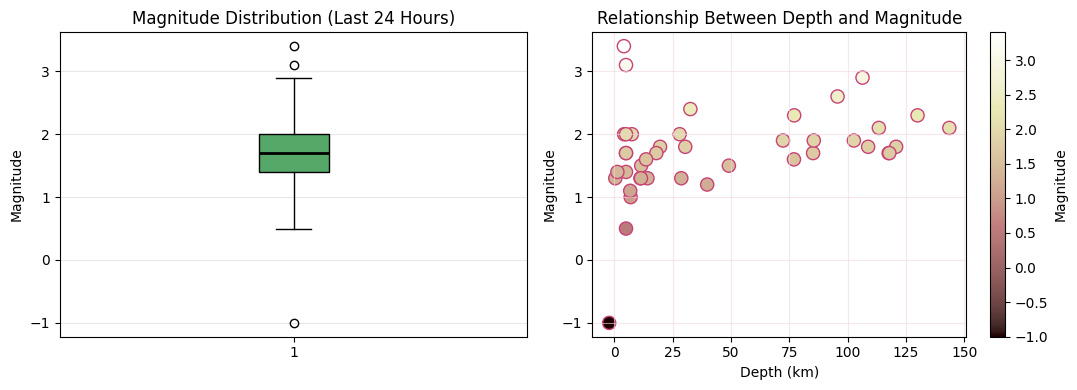

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

# ----  Box Plot (Magnitude Distribution) ----
axes[0].boxplot(
    last_24h["magnitude"],
    patch_artist=True,
    boxprops=dict(facecolor="#55A868", color="black"),
    medianprops=dict(color="black", linewidth=2)
)

axes[0].set_title("Magnitude Distribution (Last 24 Hours)")
axes[0].set_ylabel("Magnitude")
axes[0].grid(axis="y", alpha=0.3)


# ----  Depth vs Magnitude Scatter ----
sc = axes[1].scatter(
    last_24h["depth"],
    last_24h["magnitude"],
    c=last_24h["magnitude"],
    cmap="pink",
    s=90,
    edgecolor="#C74375"
)

fig.colorbar(sc, ax=axes[1], label="Magnitude")

axes[1].set_xlabel("Depth (km)")
axes[1].set_ylabel("Magnitude")
axes[1].set_title("Relationship Between Depth and Magnitude")
axes[1].grid(True, color="#F2D7DE", alpha=0.6)

plt.tight_layout()
plt.show()


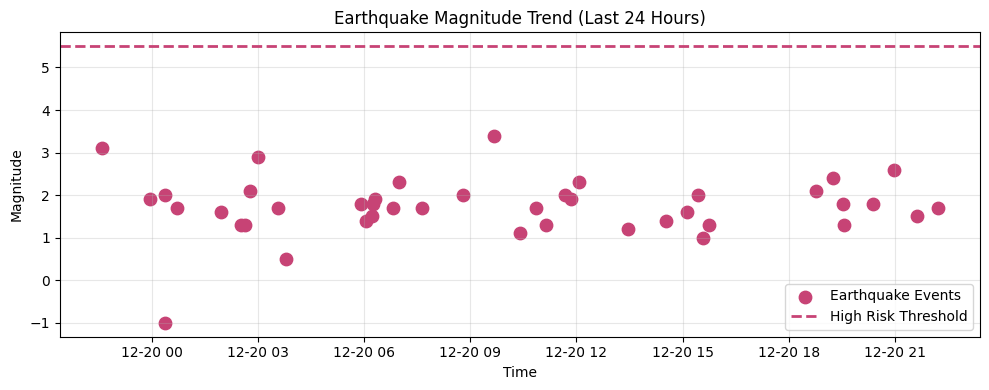

In [105]:
# Earth quake magnitude trend
plt.figure(figsize=(10,4))

plt.scatter(
    last_24h["time"],
    last_24h["magnitude"],
    color= "#C74375",
    s=80,
    label="Earthquake Events"
)

plt.axhline(
    5.5,
    color="#C74375",
    linestyle="--",
    linewidth=2,
    label="High Risk Threshold"
)

plt.title("Earthquake Magnitude Trend (Last 24 Hours)")
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
